<a href="https://colab.research.google.com/github/charanlogs/Week-04-Team-13/blob/main/Pre_processing_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# (DailyMed + CADEC)- Group 13

**Domains:** Formal (DailyMed FDA labels) + Informal (CADEC patient posts)

This single notebook:
1. **Extracts DailyMed** via the real REST API v2 (parses the `34084-4` adverse-reactions SPL section)
2. **Extracts CADEC** from your local brat-annotated files (no API/scraping)
3. **Unifies** both into the project schema: `text`, `label`, `severity`, `domain`
4. **Preprocesses** identically across both domains (so cross-domain comparison is fair)
5. **EDA** comparing the two domains
6. **Stratified 70/15/15 splits** (by domain + label) ready for Objective 2 modelling

> **Severity note:** neither dataset ships an explicit severity label. We derive it as a keyword/count **proxy** and clearly mark it as such , report it as derived.


## Quick Setup


In [2]:

!pip install -q pandas numpy matplotlib seaborn nltk scikit-learn requests

import os
import re
import glob
import time
import json
import logging
from datetime import datetime, timezone
from typing import Any, Dict, List, Optional, Tuple

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import GroupShuffleSplit
import warnings
warnings.filterwarnings("ignore")

#  levelled logging instead of bare print()
logging.basicConfig(level=logging.INFO, format="[%(levelname)s] %(message)s")
logger = logging.getLogger("ade_pipeline")

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

#  Project-wide config
N_DAILYMED = 1500
RANDOM_SEED = 42
NS = "{urn:hl7-org:v3}"
LOINC_ADVERSE = "34084-4"      # ADVERSE REACTIONS   -> positive (label 1)
LOINC_INDICATIONS = "34067-9"  # INDICATIONS & USAGE -> real negative (0)
LOINC_DOSAGE = "34068-7"       # DOSAGE & ADMIN      -> fallback negative

# formal schema as a single source of truth + validator
OUTPUT_SCHEMA: Dict[str, Dict[str, Any]] = {
    "text": {"dtype": "object", "desc": "Original raw text"},
    "text_processed": {"dtype": "object",
                       "desc": "Lemmatised, stopword-removed, space-joined"},
    "label": {"dtype": "int", "desc": "0 = no ADE, 1 = ADE"},
    "severity": {"dtype": "object",
                 "values": ["none", "mild", "moderate", "severe"],
                 "desc": "PROXY ONLY - heuristic, not ground truth"},
    "severity_source": {"dtype": "object", "desc": "Always heuristic_proxy"},
    "domain": {"dtype": "object",
               "values": ["Formal (DailyMed)", "Informal (CADEC)"]},
    "group_id": {"dtype": "object",
                 "desc": "Leakage key: dm_<setid> or cadec_<file>"},
    "word_count_processed": {"dtype": "int",
                             "desc": "Token count of text_processed"},
}


def validate_schema(df: pd.DataFrame,
                    schema: Dict[str, Dict[str, Any]] = OUTPUT_SCHEMA) -> None:
    """Assert a DataFrame matches OUTPUT_SCHEMA (Fix #3).

    Checks every required column is present, dtypes are compatible, labels
    are binary, and no processed text is empty.
    """
    for col, meta in schema.items():
        assert col in df.columns, f"Missing column: {col}"
        if meta["dtype"] == "int":
            assert pd.api.types.is_integer_dtype(df[col]), \
                f"{col}: expected int, got {df[col].dtype}"
    assert df["label"].isin([0, 1]).all(), "label must be 0/1"
    assert (df["text_processed"].str.len() > 0).all(), \
        "empty text_processed found"
    logger.info("Schema valid: %d rows x %d cols", len(df), len(schema))


#  HTTP session with retries + exponential backoff
def get_session_with_retries(retries: int = 3,
                             backoff: float = 0.3) -> requests.Session:
    """Return a requests.Session that retries transient API failures."""
    session = requests.Session()
    strategy = Retry(
        total=retries,
        backoff_factor=backoff,
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
    )
    session.mount("https://", HTTPAdapter(max_retries=strategy))
    return session


SESSION = get_session_with_retries()
logger.info("Setup ready")

##  Extract DailyMed (Formal Domain) — real API

Each label's adverse-reactions section (`34084-4`) becomes a **positive** example.
To get **real negatives** (not a placeholder sentence), we also pull a non-adverse
section — Indications & Usage (`34067-9`), falling back to Dosage (`34068-7`) — as
label 0. Both rows from one label share a `group_id`, so a drug never straddles the
train/test boundary.

In [3]:
def fetch_drug_index(num_drugs: int) -> List[Dict[str, Any]]:
    """Retrieve metadata for num_drugs labels from the DailyMed API.

    Paginated; retries transient failures via SESSION. Logs and stops early
    if the API returns an empty page mid-pull (Issue #1).
    """
    base = "https://dailymed.nlm.nih.gov/dailymed/services/v2/spls.json"
    drugs: List[Dict[str, Any]] = []
    page = 1
    while len(drugs) < num_drugs:
        r = SESSION.get(base, params={"pagesize": 100, "page": page},
                        timeout=30)
        r.raise_for_status()
        payload = r.json()
        batch = payload.get("data", [])
        if not batch:
            logger.warning("API returned empty page %d - stopping early "
                           "(requested %d, got %d).", page, num_drugs,
                           len(drugs))
            break
        drugs.extend(batch)
        total_pages = payload.get("metadata", {}).get("total_pages", page)
        logger.info("  index page %d/%s (+%d, total %d)", page, total_pages,
                    len(batch), len(drugs))
        if page >= total_pages:
            break
        page += 1
    return drugs[:num_drugs]


def extract_section_text(root: ET.Element, loinc: str) -> Optional[str]:
    """Return cleaned text of the XML section with the given LOINC code."""
    for section in root.iter(f"{NS}section"):
        c = section.find(f"{NS}code")
        if c is not None and c.get("code") == loinc:
            parts: List[str] = []
            for el in section.iter():
                if el.text and el.text.strip():
                    parts.append(el.text.strip())
                if el.tail and el.tail.strip():
                    parts.append(el.tail.strip())
            return re.sub(r"\s+", " ", " ".join(parts)).strip()
    return None


def drug_name(title: str) -> str:
    """Clean a DailyMed title ('Aspirin (Tablet)' -> 'Aspirin')."""
    return re.split(r"[(\[]", title)[0].strip().title()


# Download and process DailyMed drug labels
logger.info("Fetching DailyMed index...")
index = fetch_drug_index(N_DAILYMED)
logger.info("Got %d labels; downloading + parsing XML...", len(index))

dm_rows: List[Dict[str, Any]] = []
errors = 0
start = time.time()  # Issue #11: track throughput + ETA
for i, d in enumerate(index, 1):
    setid, title = d["setid"], d.get("title", "")
    try:
        xr = SESSION.get(
            f"https://dailymed.nlm.nih.gov/dailymed/services/v2/spls/"
            f"{setid}.xml",
            timeout=30)
        xr.raise_for_status()
        root = ET.fromstring(xr.content)
        name = drug_name(title)

        # POSITIVE (label 1): real adverse-reactions text
        adverse = extract_section_text(root, LOINC_ADVERSE)
        if adverse and len(adverse) > 30:
            dm_rows.append({
                "text": adverse,
                "drug_name": name,
                "group_id": f"dm_{setid}",
                "domain": "Formal (DailyMed)",
                "label": 1,
                "source": "DailyMed",
            })

        # NEGATIVE (label 0): real non-adverse text (indications, else dosage)
        neg = (extract_section_text(root, LOINC_INDICATIONS)
               or extract_section_text(root, LOINC_DOSAGE))
        if neg and len(neg) > 30:
            dm_rows.append({
                "text": neg,
                "drug_name": name,
                "group_id": f"dm_{setid}",
                "domain": "Formal (DailyMed)",
                "label": 0,
                "source": "DailyMed",
            })
    except Exception:  # noqa: BLE001 - count + continue on any per-label error
        errors += 1
    if i % 25 == 0:
        elapsed = time.time() - start
        rate = i / elapsed if elapsed else 0.0
        eta_min = (len(index) - i) / rate / 60 if rate else 0.0
        logger.info("  %d/%d (rows %d, errors %d, %.1f req/s, ETA %.0fm)",
                    i, len(index), len(dm_rows), errors, rate, eta_min)
    time.sleep(0.05)

dailymed_df = pd.DataFrame(dm_rows)
logger.info("DailyMed: %d rows | pos %d | neg %d | errors %d",
            len(dailymed_df), int((dailymed_df.label == 1).sum()),
            int((dailymed_df.label == 0).sum()), errors)

##  Extract CADEC (Informal Domain) — local files

Upload your CADEC zip. We read each post's `.txt` and its brat `.ann` (in `original/`), then build labels:
**label = 1 if the post has an ADR or Symptom annotation.**


In [5]:
# CADEC is already a FOLDER in Google Drive named 'cadec'; mount it.
from google.colab import drive
drive.mount("/content/drive")

CADEC_DIR = "/content/drive/MyDrive/cadec"

# Issue #7: validate the path AND confine it to Google Drive
assert os.path.isdir(CADEC_DIR), f"Not found: {CADEC_DIR}"
assert os.path.abspath(CADEC_DIR).startswith("/content/drive"), \
    "CADEC_DIR must live inside the mounted Google Drive"
logger.info("Found CADEC folder. Top-level contents: %s",
            sorted(os.listdir(CADEC_DIR))[:15])


def find_folder(base: str, name: str) -> Optional[str]:
    """Return the first subfolder of `base` whose name matches `name`."""
    for root, dirs, _ in os.walk(base):
        if os.path.basename(root).lower() == name:
            return root
        for d in dirs:
            if d.lower() == name:
                return os.path.join(root, d)
    return None


TEXT_DIR = find_folder(CADEC_DIR, "text")
ANN_DIR = find_folder(CADEC_DIR, "original")
logger.info("TEXT_DIR: %s", TEXT_DIR)
logger.info("ANN_DIR : %s", ANN_DIR)
assert TEXT_DIR and ANN_DIR, "Could not locate CADEC text/ and original/ dirs"

Mounted at /content/drive


In [6]:
def parse_ann(path: str) -> Tuple[Counter, List[str]]:
    """Parse a BRAT .ann file with validation (Issue #3).

    Returns (entity-type counts, ADR terms). Malformed lines are counted
    and logged rather than silently dropped.
    """
    counts: Counter = Counter()
    adr_terms: List[str] = []
    parse_errors = 0
    with open(path, encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line.startswith("T"):       # text-bound annotations only
                continue
            p = line.split("\t")
            if len(p) < 2:
                parse_errors += 1
                continue
            try:
                lab = p[1].split()[0]
                counts[lab] += 1
                if lab == "ADR" and len(p) > 2:
                    adr_terms.append(p[2])
            except (IndexError, ValueError):
                parse_errors += 1
    if parse_errors:
        logger.warning("%s: %d malformed annotation line(s)",
                       os.path.basename(path), parse_errors)
    return counts, adr_terms


# Build CADEC dataset from text + annotation files
cd_rows: List[Dict[str, Any]] = []
for ann in sorted(glob.glob(os.path.join(ANN_DIR, "*.ann"))):
    base = os.path.splitext(os.path.basename(ann))[0]
    txt = os.path.join(TEXT_DIR, base + ".txt")
    if not os.path.exists(txt):
        continue
    with open(txt, encoding="utf-8", errors="ignore") as f:
        text = f.read().strip()
    counts, adr_terms = parse_ann(ann)
    cd_rows.append({
        "text": text,
        "drug_name": "",
        "group_id": f"cadec_{base}",            # post-level group id
        "n_adr": counts.get("ADR", 0),
        "n_symptom": counts.get("Symptom", 0),
        "adr_terms": "; ".join(adr_terms),
        "domain": "Informal (CADEC)",
        "source": "CADEC",
    })

cadec_df = pd.DataFrame(cd_rows)

# Label: 1 if the post has an ADR or Symptom annotation, else 0
cadec_df["label"] = (
    (cadec_df["n_adr"] > 0) | (cadec_df["n_symptom"] > 0)).astype(int)
logger.info("CADEC: %d posts | pos %d | neg %d", len(cadec_df),
            int((cadec_df.label == 1).sum()),
            int((cadec_df.label == 0).sum()))

##  Derive severity & unify to the project schema

Same severity heuristic applied to **both** domains for consistency, then both are reduced to `text, label, severity, domain`.


 ## Severity keyword lexicons
 SK and MK

In [7]:
# severity thresholds documented (rationale + caveat)

SEVERE_KW = ["hospital", "emergency", " er ", "a&e", "ambulance", "severe",
             "unbearable", "collapsed", "seizure", "anaphyla", "death",
             "fatal", "life-threatening", "swelling", "swelled"]
MODERATE_KW = ["stopped taking", "had to stop", "discontinued", "unable to",
               "couldn't", "painful", "vomiting", "debilitating", "interfere"]


def severity_from_text(text: str, label: int, adr_count: int = 0) -> str:
    """Rule-based severity tier. PROXY only - see severity_source column."""
    if label == 0:
        return "none"
    t = str(text).lower()
    if any(k in t for k in SEVERE_KW) or adr_count >= 4:
        return "severe"
    if any(k in t for k in MODERATE_KW) or adr_count >= 2:
        return "moderate"
    return "mild"


dailymed_df["severity"] = dailymed_df.apply(
    lambda r: severity_from_text(r["text"], r["label"]), axis=1)
cadec_df["severity"] = cadec_df.apply(
    lambda r: severity_from_text(r["text"], r["label"], r["n_adr"]), axis=1)

# Tag severity as a derived proxy so it is never mistaken for truth
dailymed_df["severity_source"] = "heuristic_proxy"
cadec_df["severity_source"] = "heuristic_proxy"

keep = ["text", "label", "severity", "severity_source", "domain",
        "group_id", "source"]
dailymed_keep = dailymed_df[keep + ["drug_name"]]
cadec_keep = cadec_df[keep].assign(drug_name="")
df = pd.concat([dailymed_keep, cadec_keep], ignore_index=True)


# Normalised dedup (lowercase, strip urls, collapse whitespace)
def _norm(t: str) -> str:
    t = re.sub(r"http\S+|www\S+", " ", str(t).lower())
    return re.sub(r"\s+", " ", t).strip()


df["_norm"] = df["text"].map(_norm)
before = len(df)
df = (df.dropna(subset=["text"])
        .drop_duplicates(subset=["_norm"])
        .drop(columns="_norm")
        .reset_index(drop=True))
logger.info("Dropped %d duplicate / near-duplicate rows", before - len(df))

logger.info("Unified dataset: %s", df.shape)
print("\nBy domain:"); print(df["domain"].value_counts())
print("\nBy label:"); print(df["label"].value_counts())
print("\nBy severity:"); print(df["severity"].value_counts())


By domain:
domain
Formal (DailyMed)    1831
Informal (CADEC)     1248
Name: count, dtype: int64

By label:
label
1    1853
0    1226
Name: count, dtype: int64

By severity:
severity
severe      1393
none        1226
moderate     309
mild         151
Name: count, dtype: int64


##  Preprocess (identical pipeline for both domains)

### Initialise NLP preprocessing tools


In [8]:
# WordNetLemmatizer reduces inflected forms to a base ("vomiting" -> "vomit"),
# improving vocabulary consistency across DailyMed prose and CADEC posts.
lemm = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))


def clean_text(t: str) -> str:
    """Lightweight structural normalisation - runs BEFORE tokenisation."""
    t = str(t).lower()
    t = re.sub(r"http\S+|www\S+|\S+@\S+", "", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


def tokenize(t: str) -> List[str]:
    """Convert a cleaned string into lemmatised, filtered tokens."""
    t = re.sub(r"[^a-z0-9\s]", "", t)
    return [lemm.lemmatize(w) for w in t.split()
            if w not in stop_words and len(w) >= 3]


# Apply the preprocessing pipeline. We compute tokens in a TEMP variable and
# only persist text_processed + word_count_processed

_tokens = df["text"].apply(clean_text).apply(tokenize)
df["text_processed"] = _tokens.apply(" ".join)
df["word_count"] = df["text"].str.split().str.len()
df["word_count_processed"] = df["text_processed"].str.split().str.len()

# Drop rows that became empty after cleaning
df = df[df["word_count_processed"] > 0].reset_index(drop=True)

# enforce text_processed/word_count_processed consistency
assert (df["text_processed"].str.split().str.len()
        == df["word_count_processed"]).all(), \
    "word_count_processed does not match text_processed"
logger.info("Column consistency check passed")

# Issue #2: report preprocessing compression so we catch over-aggressive
# stopword removal (e.g. a long formal doc collapsing to a handful of tokens)
for dom in df["domain"].unique():
    sub = df[df["domain"] == dom]
    q05 = sub["word_count_processed"].quantile(0.05)
    compression = 1 - (sub["word_count_processed"].sum()
                       / max(sub["word_count"].sum(), 1))
    logger.info("%s | 5th-pct tokens %.0f | mean compression %.0f%%",
                dom, q05, compression * 100)
    if q05 < 20 and "Formal" in dom:
        logger.warning("Formal domain very short after preprocessing - "
                       "consider tuning the stopword list.")

logger.info("After preprocessing: %s", df.shape)
df[["domain", "label", "severity", "text", "text_processed"]].head(4)

,domain,label,severity,text,text_processed
0,Formal (DailyMed),1,severe,6 ADVERSE REACTIONS The following serious adve...,adverse reaction following serious adverse rea...
1,Formal (DailyMed),0,none,1 INDICATIONS AND USAGE Pregabalin is indicate...,indication usage pregabalin indicated manageme...
2,Formal (DailyMed),1,severe,6 ADVERSE REACTIONS The following serious adve...,adverse reaction following serious adverse rea...
3,Formal (DailyMed),0,none,"1 INDICATIONS AND USAGE Trilitas™ gel, 0.1% is...",indication usage trilitas gel retinoid indicat...


##  Cross-Domain EDA


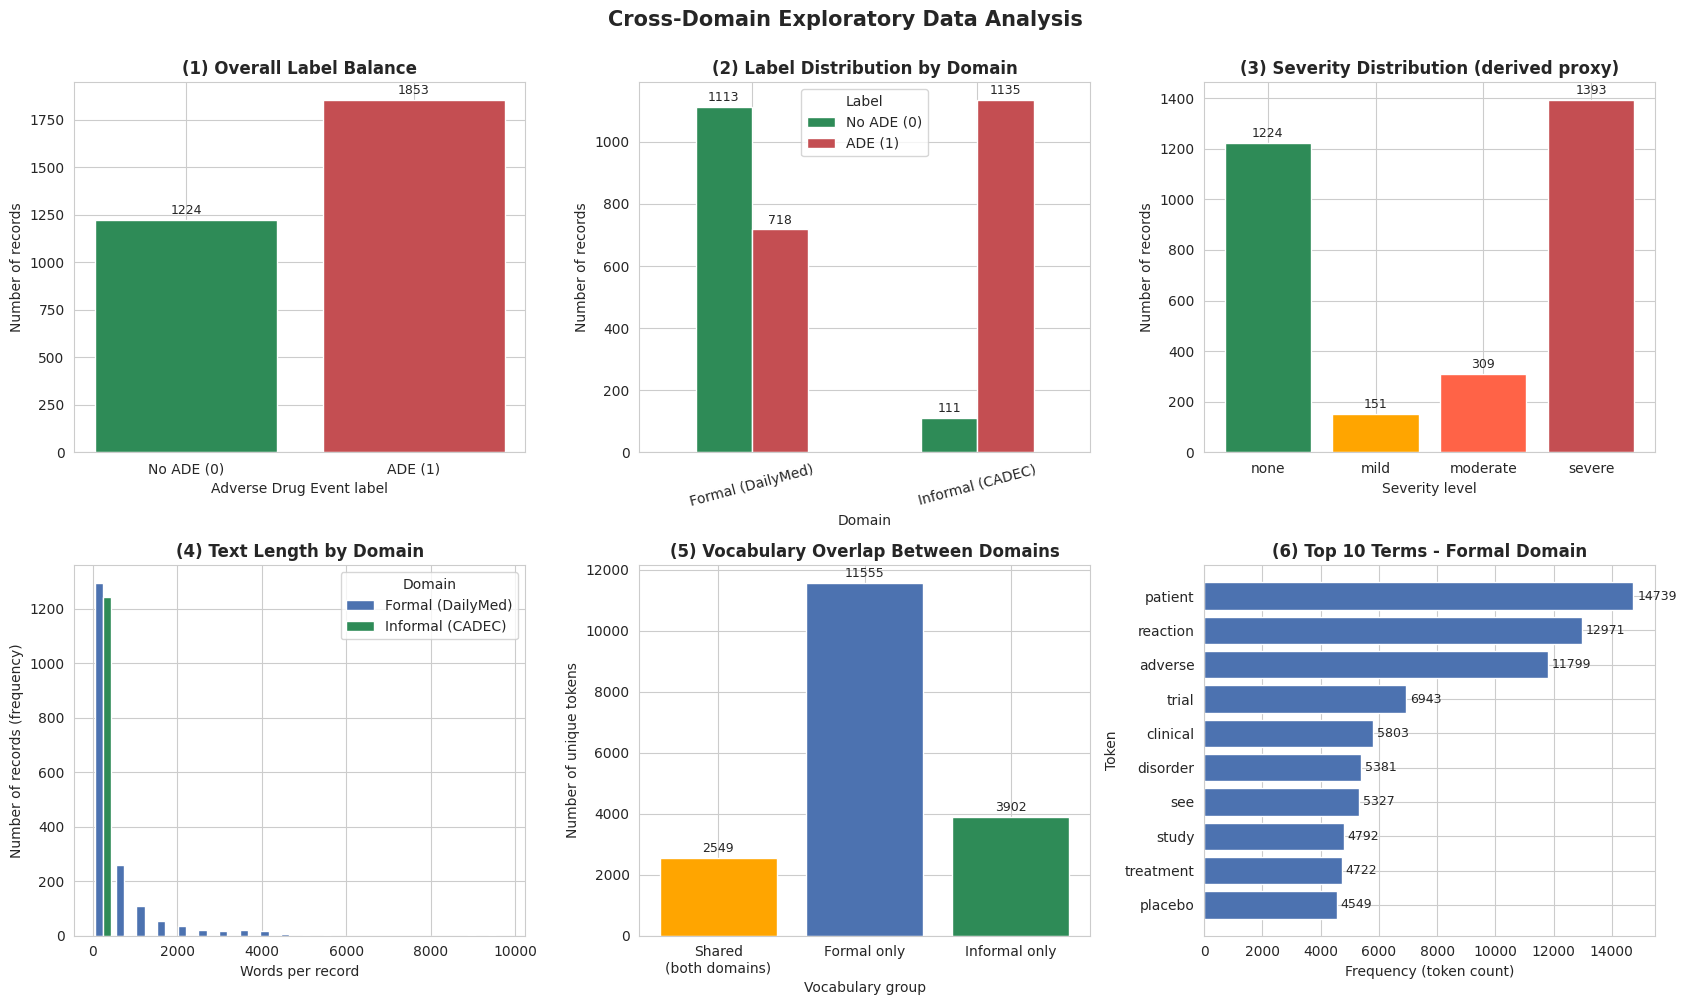

In [9]:
# Split dataset into formal and informal domains
formal = df[df["domain"].str.contains("Formal")]
informal = df[df["domain"].str.contains("Informal")]


def label_bars(ax, fmt: str = "{:.0f}", fontsize: int = 9) -> None:
    """Annotate each vertical bar with its value."""
    for p in ax.patches:
        h = p.get_height()
        if h and not np.isnan(h):
            ax.annotate(fmt.format(h),
                        (p.get_x() + p.get_width() / 2, h),
                        ha="center", va="bottom", fontsize=fontsize,
                        xytext=(0, 2), textcoords="offset points")


def label_hbars(ax, fontsize: int = 9) -> None:
    """Annotate each horizontal bar with its value."""
    for p in ax.patches:
        w = p.get_width()
        if w and not np.isnan(w):
            ax.annotate(f"{w:.0f}",
                        (w, p.get_y() + p.get_height() / 2),
                        ha="left", va="center", fontsize=fontsize,
                        xytext=(3, 0), textcoords="offset points")


# build vocabularies from text_processed.split() (robust whether the
# frame is in-memory or reloaded from CSV; the old code iterated a token list
# that becomes a STRING after a CSV round-trip, counting characters).

fvoc = Counter(w for text in formal["text_processed"] for w in text.split())
ivoc = Counter(w for text in informal["text_processed"] for w in text.split())
overlap = len(set(fvoc) & set(ivoc))

fig, ax = plt.subplots(2, 3, figsize=(17, 10))
fig.suptitle("Cross-Domain Exploratory Data Analysis",
             fontsize=15, fontweight="bold", y=1.00)

# (1) Overall label balance
counts = df["label"].value_counts().sort_index()
ax[0, 0].bar(["No ADE (0)", "ADE (1)"], counts.values,
             color=["#2E8B57", "#C44E52"])
ax[0, 0].set_title("(1) Overall Label Balance", fontweight="bold")
ax[0, 0].set_xlabel("Adverse Drug Event label")
ax[0, 0].set_ylabel("Number of records")
label_bars(ax[0, 0])

# (2) Label by domain
ct = pd.crosstab(df["domain"], df["label"])
ct.plot(kind="bar", ax=ax[0, 1], color=["#2E8B57", "#C44E52"])
ax[0, 1].set_title("(2) Label Distribution by Domain", fontweight="bold")
ax[0, 1].set_xlabel("Domain")
ax[0, 1].set_ylabel("Number of records")
ax[0, 1].tick_params(axis="x", rotation=15)
ax[0, 1].legend(["No ADE (0)", "ADE (1)"], title="Label")
label_bars(ax[0, 1])

# (3) Severity (derived proxy)
order = ["none", "mild", "moderate", "severe"]
sev = df["severity"].value_counts().reindex(order).fillna(0)
ax[0, 2].bar(order, sev.values,
             color=["#2E8B57", "#FFA500", "#FF6347", "#C44E52"])
ax[0, 2].set_title("(3) Severity Distribution (derived proxy)",
                   fontweight="bold")
ax[0, 2].set_xlabel("Severity level")
ax[0, 2].set_ylabel("Number of records")
label_bars(ax[0, 2])

# (4) Text length by domain
ax[1, 0].hist([formal["word_count"], informal["word_count"]], bins=20,
              label=["Formal (DailyMed)", "Informal (CADEC)"],
              color=["#4C72B0", "#2E8B57"])
ax[1, 0].set_title("(4) Text Length by Domain", fontweight="bold")
ax[1, 0].set_xlabel("Words per record")
ax[1, 0].set_ylabel("Number of records (frequency)")
ax[1, 0].legend(title="Domain")

# (5) Vocabulary overlap
vals = [overlap, len(set(fvoc) - set(ivoc)), len(set(ivoc) - set(fvoc))]
ax[1, 1].bar(["Shared\n(both domains)", "Formal only", "Informal only"],
             vals, color=["#FFA500", "#4C72B0", "#2E8B57"])
ax[1, 1].set_title("(5) Vocabulary Overlap Between Domains", fontweight="bold")
ax[1, 1].set_xlabel("Vocabulary group")
ax[1, 1].set_ylabel("Number of unique tokens")
label_bars(ax[1, 1])

# (6) Top 10 formal-domain terms
topf = fvoc.most_common(10)
if topf:
    words, freqs = zip(*topf)
    ax[1, 2].barh(words, freqs, color="#4C72B0")
    ax[1, 2].invert_yaxis()
    ax[1, 2].set_title("(6) Top 10 Terms - Formal Domain", fontweight="bold")
    ax[1, 2].set_xlabel("Frequency (token count)")
    ax[1, 2].set_ylabel("Token")
    label_hbars(ax[1, 2])

plt.tight_layout()
plt.savefig("unified_eda.png", dpi=120, bbox_inches="tight")
plt.show()

logger.info("Formal avg words: %.1f | Informal avg words: %.1f",
            formal["word_count"].mean(), informal["word_count"].mean())
logger.info("Vocabulary overlap: %d shared tokens", overlap)

##  Group-aware, domain-stratified 70/15/15 splits

Splitting is done **per domain** (preserves the formal/informal ratio) and on
`group_id` (a drug's two rows, or a post, stay together) — so no drug or post
leaks across train/test. A hard assertion verifies no group spans two splits.

In [10]:
def group_aware_split(
        data: pd.DataFrame,
        group_col: str = "group_id",
        domain_col: str = "domain",
        seed: int = RANDOM_SEED,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Split into 70% train / 15% val / 15% test, group- and domain-aware.

    Strategy:
      1. Group by domain (Formal/Informal) so the domain ratio is preserved
         in every split.
      2. Within each domain, split on group_id (drug/post) so a group's rows
         never straddle two splits - this is what prevents leakage.
      3. First split 70/30 -> train / temp.
      4. Second split of temp 50/50 -> val / test (i.e. 15% / 15% overall).
    """
    tr, va, te = [], [], []
    for _, sub in data.groupby(domain_col):
        # 70% train, 30% temp (val + test combined)
        gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
        train_idx, temp_idx = next(gss1.split(sub, groups=sub[group_col]))
        sub_train, sub_temp = sub.iloc[train_idx], sub.iloc[temp_idx]
        # split temp 50/50 -> val / test
        gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
        val_idx, test_idx = next(
            gss2.split(sub_temp, groups=sub_temp[group_col]))
        tr.append(sub_train)
        va.append(sub_temp.iloc[val_idx])
        te.append(sub_temp.iloc[test_idx])
    return (pd.concat(tr, ignore_index=True),
            pd.concat(va, ignore_index=True),
            pd.concat(te, ignore_index=True))


train_df, val_df, test_df = group_aware_split(df)

# Hard leakage check: no group_id may appear in more than one split
g_tr = set(train_df.group_id)
g_va = set(val_df.group_id)
g_te = set(test_df.group_id)
assert not (g_tr & g_va), "Leakage train/val"
assert not (g_tr & g_te), "Leakage train/test"
assert not (g_va & g_te), "Leakage val/test"
logger.info("Leakage check passed: no group_id shared across splits.")

logger.info("Train %d (%.0f%%) | Val %d (%.0f%%) | Test %d (%.0f%%)",
            len(train_df), len(train_df) / len(df) * 100,
            len(val_df), len(val_df) / len(df) * 100,
            len(test_df), len(test_df) / len(df) * 100)

print("\nDistribution check (% ADE+ , % Formal):")
for name, s in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"  {name}: ADE+ {(s.label == 1).mean() * 100:4.1f}%  "
          f"Formal {s.domain.str.contains('Formal').mean() * 100:4.1f}%")


Distribution check (% ADE+ , % Formal):
  Train: ADE+ 60.0%  Formal 59.6%
  Val: ADE+ 61.5%  Formal 60.2%
  Test: ADE+ 60.1%  Formal 58.5%


##  Export for modelling


In [11]:
# Modelling columns
out_cols = ["text", "text_processed", "label", "severity",
            "severity_source", "domain", "group_id", "word_count_processed"]

# validate the schema on every split BEFORE writing anything
for split_df in (train_df, val_df, test_df):
    validate_schema(split_df[out_cols])

train_df[out_cols].to_csv("train.csv", index=False)
val_df[out_cols].to_csv("val.csv", index=False)
test_df[out_cols].to_csv("test.csv", index=False)
df[out_cols].to_csv("unified_full.csv", index=False)
train_df.to_pickle("train.pkl")
val_df.to_pickle("val.pkl")
test_df.to_pickle("test.pkl")

# Provenance manifest (what was pulled, when, how)
provenance = {
    "pull_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "n_dailymed_requested": N_DAILYMED,
    "random_seed": RANDOM_SEED,
    "total_rows": int(len(df)),
    "formal_rows": int(df.domain.str.contains("Formal").sum()),
    "informal_rows": int(df.domain.str.contains("Informal").sum()),
    "positives": int((df.label == 1).sum()),
    "negatives": int((df.label == 0).sum()),
    "loinc_positive": LOINC_ADVERSE,
    "loinc_negative": [LOINC_INDICATIONS, LOINC_DOSAGE],
    "severity": "heuristic_proxy (derived, not ground truth)",
    "output_schema": list(out_cols),
}
with open("provenance.json", "w") as f:
    json.dump(provenance, f, indent=2)

logger.info("Saved: train/val/test (.csv + .pkl), unified_full.csv, "
            "provenance.json")
print(json.dumps(provenance, indent=2))

{
  "pull_timestamp_utc": "2026-06-16T11:36:37.819935+00:00",
  "n_dailymed_requested": 1500,
  "random_seed": 42,
  "total_rows": 3077,
  "formal_rows": 1831,
  "informal_rows": 1246,
  "positives": 1853,
  "negatives": 1224,
  "loinc_positive": "34084-4",
  "loinc_negative": [
    "34067-9",
    "34068-7"
  ],
  "severity": "heuristic_proxy (derived, not ground truth)",
  "output_schema": [
    "text",
    "text_processed",
    "label",
    "severity",
    "severity_source",
    "domain",
    "group_id",
    "word_count_processed"
  ]
}
